# Detection via Gemini Vision for proof of concept

In [ ]:
prompt = """
Analyze this mirror selfie for a digital wardrobe.

Identify every clearly visible clothing and footwear item being worn by the person.

For every item, return:

- category
- type: top, bottom, outerwear, footwear, accessory
- primary_color (in hex)
- secondary_color (in hex)
- pattern
- confidence
- bounding_box

The bounding_box must be provided as:

[ymin, xmin, ymax, xmax]

Coordinates must be normalized from 0 to 1000.

The bounding box should tightly surround the clothing item itself.
Do not include unnecessary background, the mirror, the phone, or unrelated body parts where possible.

Only identify clothing and footwear that are actually being worn.

Do not identify:
- the person
- skin
- hair
- mirror
- phone
- furniture
- walls
- background objects

If an item is partially obscured but clearly identifiable, include it and reduce the confidence score accordingly.

Do not invent items that cannot be clearly seen.

Return ONLY valid JSON in exactly this format (no need to wrap in a JSON markdown code bloc, just the plain text):

{
  "items": [
    {
      "category": "hoodie",
      "type": "top",
      "primary_color": "black",
      "secondary_color": null,
      "pattern": "plain",
      "confidence": 0.95,
      "bounding_box": [200, 300, 550, 700]
    }
  ]
}
"""

In [50]:
import os
import json
from google import genai
from google.genai import types
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

def analyze_outfit(image_path: str):
    try:
        with open(image_path, "rb") as image_file:
            response = client.models.generate_content(
                model="gemini-3.5-flash-lite",
                contents=[
                    types.Part.from_text(text=prompt),
                    types.Part.from_bytes(
                        data=image_file.read(),
                        mime_type="image/jpeg"
                    )
                ],
            )

        return json.loads(response.text)
    except Exception as error:
        return {"error": str(error)}

In [51]:
image_path = "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/test-images/test_1.png"

In [52]:
result = analyze_outfit(image_path)

In [53]:
res = json.dumps(result, indent=2)
print(res)

{
  "items": [
    {
      "category": "dress shirt",
      "type": "top",
      "primary_color": "#a8c2d6",
      "secondary_color": null,
      "pattern": "plain",
      "confidence": 0.95,
      "bounding_box": [
        342,
        0,
        775,
        650
      ]
    },
    {
      "category": "pants",
      "type": "bottom",
      "primary_color": "#1f2226",
      "secondary_color": null,
      "pattern": "plain",
      "confidence": 0.9,
      "bounding_box": [
        725,
        126,
        995,
        571
      ]
    }
  ]
}


In [54]:
# TODO: Plot boxes on image and extract whats inside the ihe bounded box

In [55]:
res = json.loads(res)

In [56]:
items = [i for i in res["items"]]
print(items, len(items))

[{'category': 'dress shirt', 'type': 'top', 'primary_color': '#a8c2d6', 'secondary_color': None, 'pattern': 'plain', 'confidence': 0.95, 'bounding_box': [342, 0, 775, 650]}, {'category': 'pants', 'type': 'bottom', 'primary_color': '#1f2226', 'secondary_color': None, 'pattern': 'plain', 'confidence': 0.9, 'bounding_box': [725, 126, 995, 571]}] 2


In [57]:
import cv2

In [58]:
def plot_boxes(image_path: str, items_list: list):
    for item in items_list:
        image = cv2.imread(image_path)
        ymin, xmin, ymax, xmax = item['bounding_box']
        start_point = (xmin, ymin)
        end_point = (xmax, ymax)
        color = (0, 255, 0)
        thickness = 2
        cv2.rectangle(image, start_point, end_point, color, thickness)

    return image

In [ ]:
import matplotlib.pyplot as plt

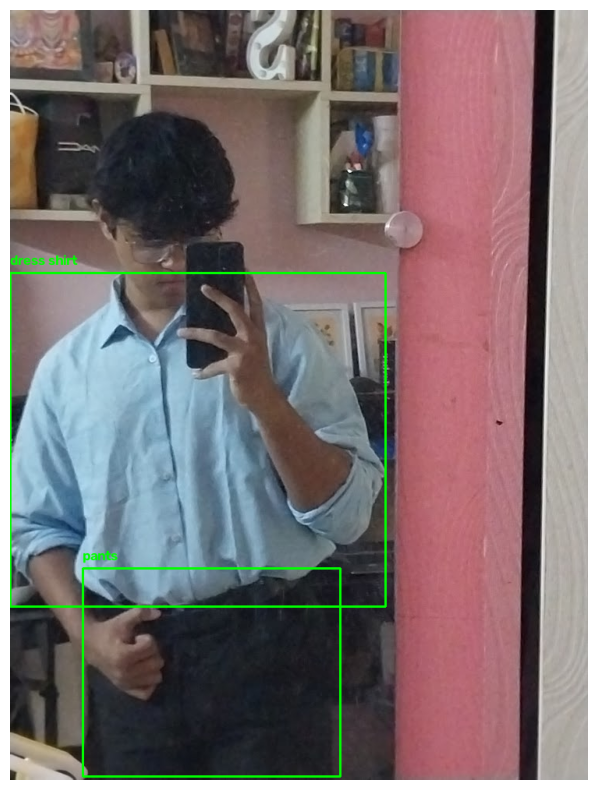

In [63]:
def plot_boxes(image_path: str, items_list: list):
    image = cv2.imread(image_path)
    height, width = image.shape[:2]

    crop_dir = os.path.join(os.path.dirname(image_path), "crops")
    os.makedirs(crop_dir, exist_ok=True)

    for index, item in enumerate(items_list):
        ymin, xmin, ymax, xmax = item["bounding_box"]

        x1 = max(0, int(xmin / 1000 * width))
        y1 = max(0, int(ymin / 1000 * height))
        x2 = min(width, int(xmax / 1000 * width))
        y2 = min(height, int(ymax / 1000 * height))

        # Crop before adding annotations
        cropped_to_item = image[y1:y2, x1:x2]
        crop_path = os.path.join(
            crop_dir, f"{index}_{item['category'].replace(' ', '_')}.png"
        )
        cv2.imwrite(crop_path, cropped_to_item)

        # Draw box only on the displayed image
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            image,
            item["category"],
            (x1, max(y1 - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
        )

    return image


boxed_image = plot_boxes(image_path, items)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(boxed_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

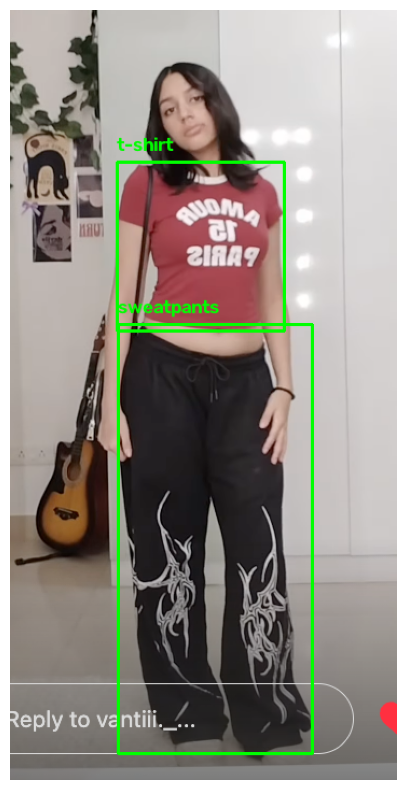

In [65]:
image_path = "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/test-images/test_2.png"
result = analyze_outfit(image_path)
res = json.dumps(result, indent=2)
res = json.loads(res)
items = [i for i in res["items"]]

boxed_image = plot_boxes(image_path, items)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(boxed_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [66]:
print(items)

[{'category': 't-shirt', 'type': 'top', 'primary_color': '#a83842', 'secondary_color': '#ffffff', 'pattern': 'graphic', 'confidence': 0.95, 'bounding_box': [197, 278, 417, 708]}, {'category': 'sweatpants', 'type': 'bottom', 'primary_color': '#1c1b1f', 'secondary_color': '#e0e0e0', 'pattern': 'graphic', 'confidence': 0.95, 'bounding_box': [409, 280, 966, 781]}]


The entire pipeline now:

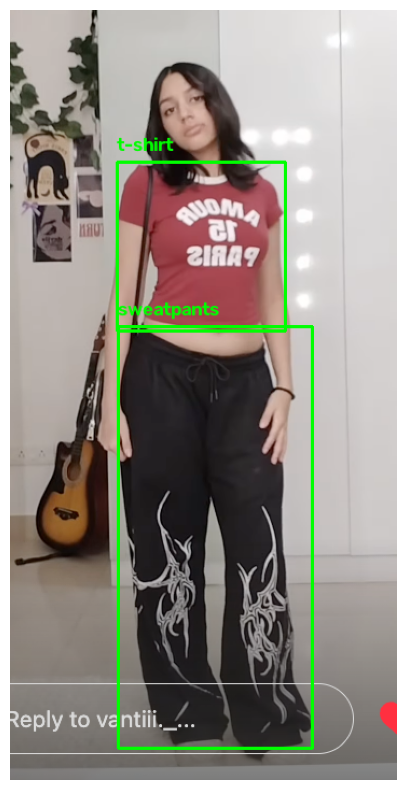

{
  "source_image": "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/test-images/test_2.png",
  "annotated_image": "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/digital_wardrobe/annotated/test_2_annotated.png",
  "items": [
    {
      "category": "t-shirt",
      "type": "top",
      "primary_color": "#a83842",
      "secondary_color": "#ffffff",
      "pattern": "graphic",
      "confidence": 0.95,
      "bounding_box": [
        197,
        276,
        417,
        712
      ],
      "source_image": "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/test-images/test_2.png",
      "crop_path": "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/digital_wardrobe/crops/test_2_0_t-shirt.png",
      "annotated_image": "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/digital_wardrobe/annotated/test_2_annotated.png"
    },
    {
      "category": "sweatpants",
      "type": "bottom",
  

In [67]:
class DigitalWardrobePipeline:
    def __init__(self, client=None, output_dir="digital_wardrobe"):
        self.client = client or globals()["client"]
        self.output_dir = output_dir
        self.annotated_dir = os.path.join(output_dir, "annotated")
        self.crops_dir = os.path.join(output_dir, "crops")
        self.uploads_dir = os.path.join(output_dir, "uploads")
        self.manifest_path = os.path.join(output_dir, "wardrobe.json")

        for directory in [
            self.output_dir,
            self.annotated_dir,
            self.crops_dir,
            self.uploads_dir,
        ]:
            os.makedirs(directory, exist_ok=True)

        if os.path.exists(self.manifest_path):
            with open(self.manifest_path, "r") as file:
                self.wardrobe = json.load(file)
        else:
            self.wardrobe = []

    def analyze(self, image_path):
        with open(image_path, "rb") as image_file:
            response = self.client.models.generate_content(
                model="gemini-3.5-flash-lite",
                contents=[
                    types.Part.from_text(text=prompt),
                    types.Part.from_bytes(
                        data=image_file.read(),
                        mime_type="image/jpeg",
                    ),
                ],
            )

        text = response.text.strip()

        if text.startswith("```"):
            text = text.replace("```json", "").replace("```", "").strip()

        return json.loads(text)

    def _save_manifest(self):
        with open(self.manifest_path, "w") as file:
            json.dump(self.wardrobe, file, indent=2)

    def process_image(self, image_path, display=True):
        analysis = self.analyze(image_path)
        items = analysis.get("items", [])

        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Could not read image: {image_path}")

        height, width = image.shape[:2]
        image_name = os.path.splitext(os.path.basename(image_path))[0]

        annotated_path = os.path.join(
            self.annotated_dir,
            f"{image_name}_annotated.png",
        )

        processed_items = []

        for index, item in enumerate(items):
            ymin, xmin, ymax, xmax = item["bounding_box"]

            x1 = max(0, min(width, int(xmin / 1000 * width)))
            y1 = max(0, min(height, int(ymin / 1000 * height)))
            x2 = max(0, min(width, int(xmax / 1000 * width)))
            y2 = max(0, min(height, int(ymax / 1000 * height)))

            crop = image[y1:y2, x1:x2]
            category = item.get("category", "unknown").replace(" ", "_")

            crop_path = os.path.join(
                self.crops_dir,
                f"{image_name}_{index}_{category}.png",
            )
            cv2.imwrite(crop_path, crop)

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2,
            )
            cv2.putText(
                image,
                item.get("category", "unknown"),
                (x1, max(y1 - 10, 0)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2,
            )

            processed_item = {
                **item,
                "source_image": os.path.abspath(image_path),
                "crop_path": os.path.abspath(crop_path),
                "annotated_image": os.path.abspath(annotated_path),
            }

            processed_items.append(processed_item)

        cv2.imwrite(annotated_path, image)

        record = {
            "source_image": os.path.abspath(image_path),
            "annotated_image": os.path.abspath(annotated_path),
            "items": processed_items,
        }

        self.wardrobe.append(record)
        self._save_manifest()

        if display:
            plt.figure(figsize=(10, 10))
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.show()

        return record

    def process_images(self, image_paths, display=True):
        return [
            self.process_image(image_path, display=display)
            for image_path in image_paths
        ]

    def upload_clothing(self, clothing_path, metadata=None):
        filename = os.path.basename(clothing_path)
        destination = os.path.join(self.uploads_dir, filename)

        with open(clothing_path, "rb") as source:
            with open(destination, "wb") as target:
                target.write(source.read())

        entry = {
            "uploaded_path": os.path.abspath(destination),
            "metadata": metadata or {},
        }

        self.wardrobe.append(entry)
        self._save_manifest()
        return entry

    def get_wardrobe(self):
        return self.wardrobe

    def save_wardrobe(self, path=None):
        path = path or self.manifest_path

        with open(path, "w") as file:
            json.dump(self.wardrobe, file, indent=2)

        return os.path.abspath(path)


wardrobe = DigitalWardrobePipeline(client=client)

record = wardrobe.process_image(image_path)
print(json.dumps(record, indent=2))

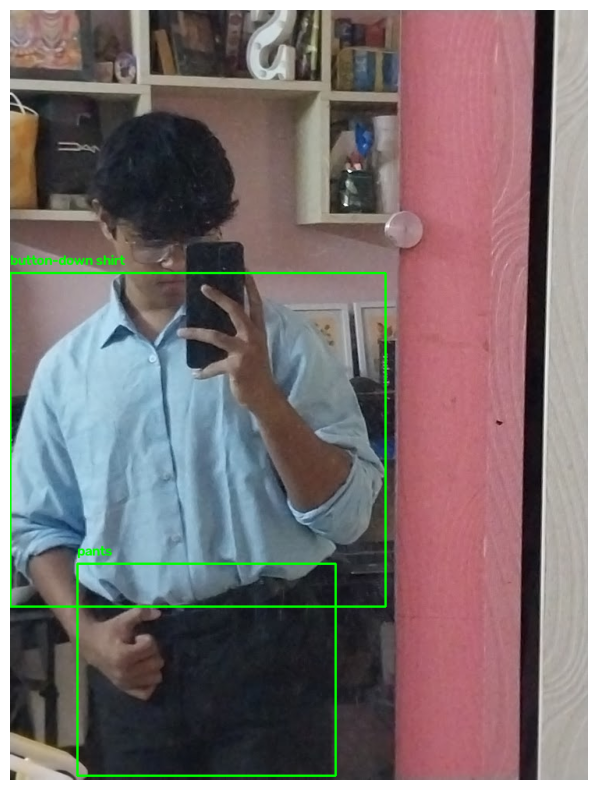

{
  "source_image": "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/test-images/test_1.png",
  "annotated_image": "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/digital_wardrobe/annotated/test_1_annotated.png",
  "items": [
    {
      "category": "button-down shirt",
      "type": "top",
      "primary_color": "#add8e6",
      "secondary_color": null,
      "pattern": "plain",
      "confidence": 0.95,
      "bounding_box": [
        342,
        0,
        775,
        650
      ],
      "source_image": "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/test-images/test_1.png",
      "crop_path": "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/digital_wardrobe/crops/test_1_0_button-down_shirt.png",
      "annotated_image": "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/digital_wardrobe/annotated/test_1_annotated.png"
    },
    {
      "category": "pants",
      "type": "botto

In [68]:
image_path = "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/test-images/test_1.png"
record = wardrobe.process_image(image_path)
print(json.dumps(record, indent=2))